In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import sympy  as sp
import numpy  as np
import mpmath as mp
import matplotlib.pyplot as plt
import os

from scipy.stats import wasserstein_distance
from scipy.signal import find_peaks

In [5]:
TARGET = 'x'
TEST   = 3
VIEW_LIMITS = (20, 150)

In [6]:
tables  = [os.path.join('files', file) for file in os.listdir('files') if '.csv' in file]
tables

['files/test_1_x.csv',
 'files/test_3_z.csv',
 'files/test_2_x.csv',
 'files/test_3_x.csv']

In [7]:
df = pd.read_csv(f'files/test_{TEST}_{TARGET}.csv')
df

,pitch,time,wz,wy,ax,roll,wx,ay,yaw,az,e
0,-8589.0,41.481998,0.0,1.0,-30.0,5492.0,-1.0,-497.0,33827.0,21.0,0.0
1,-8589.0,41.492001,1.0,0.0,-29.0,5494.0,-1.0,-498.0,33826.0,21.0,0.0
2,-8589.0,41.501999,0.0,-1.0,-29.0,5494.0,0.0,-498.0,33826.0,21.0,0.0
3,-8589.0,41.512001,1.0,0.0,-29.0,5495.0,-1.0,-497.0,33824.0,20.0,0.0
4,-8589.0,41.512001,1.0,0.0,-29.0,5495.0,-1.0,-497.0,33824.0,20.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
35273,-8591.0,462.562012,0.0,0.0,-28.0,5469.0,-1.0,-497.0,33837.0,20.0,0.0
35274,-8591.0,462.571991,0.0,1.0,-28.0,5468.0,1.0,-499.0,33838.0,21.0,0.0
35275,-8592.0,462.582001,0.0,0.0,-29.0,5469.0,-1.0,-498.0,33836.0,22.0,0.0
35276,-8592.0,462.592010,1.0,1.0,-29.0,5471.0,-1.0,-497.0,33835.0,20.0,0.0


# VERIFICANDO PERIODO DE AMOSTRAGEM 

array:  [0.01000214 0.00999832 0.01000214 ... 0.01000977 0.01000977 0.        ]
period: 0.01


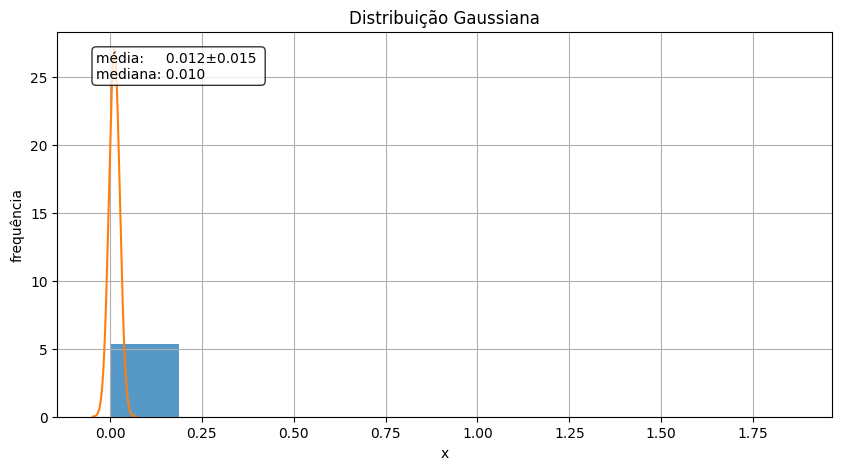

In [8]:
def gaussian(data):
    data  = np.array(data)
    n     = data.shape[0]
    mu    = data.mean()
    sigma = data.std()

    x  = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
    y  = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x - mu)/sigma)**2)
    plt.figure(figsize=(10, 5))
    plt.title(f'Distribuição Gaussiana')
    plt.hist(data, density=True, alpha=0.75)
    plt.plot(x, y)
    
    text = f'média:     {mu:.3f}±{sigma:.3f} \nmediana: {np.median(data):.3f}'
    opts = dict(boxstyle='round', facecolor='white', alpha=0.8)
    plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, verticalalignment='top', bbox=opts)
    plt.xlabel('x'); plt.ylabel('frequência'); plt.grid()


time = df.time.diff()[1:].to_numpy()
dt   = np.median(time).round(3)

print('array: ', time)
print('period:', dt)
gaussian(time)

# VISUALIZAÇÃO GERAL SENSORIAL

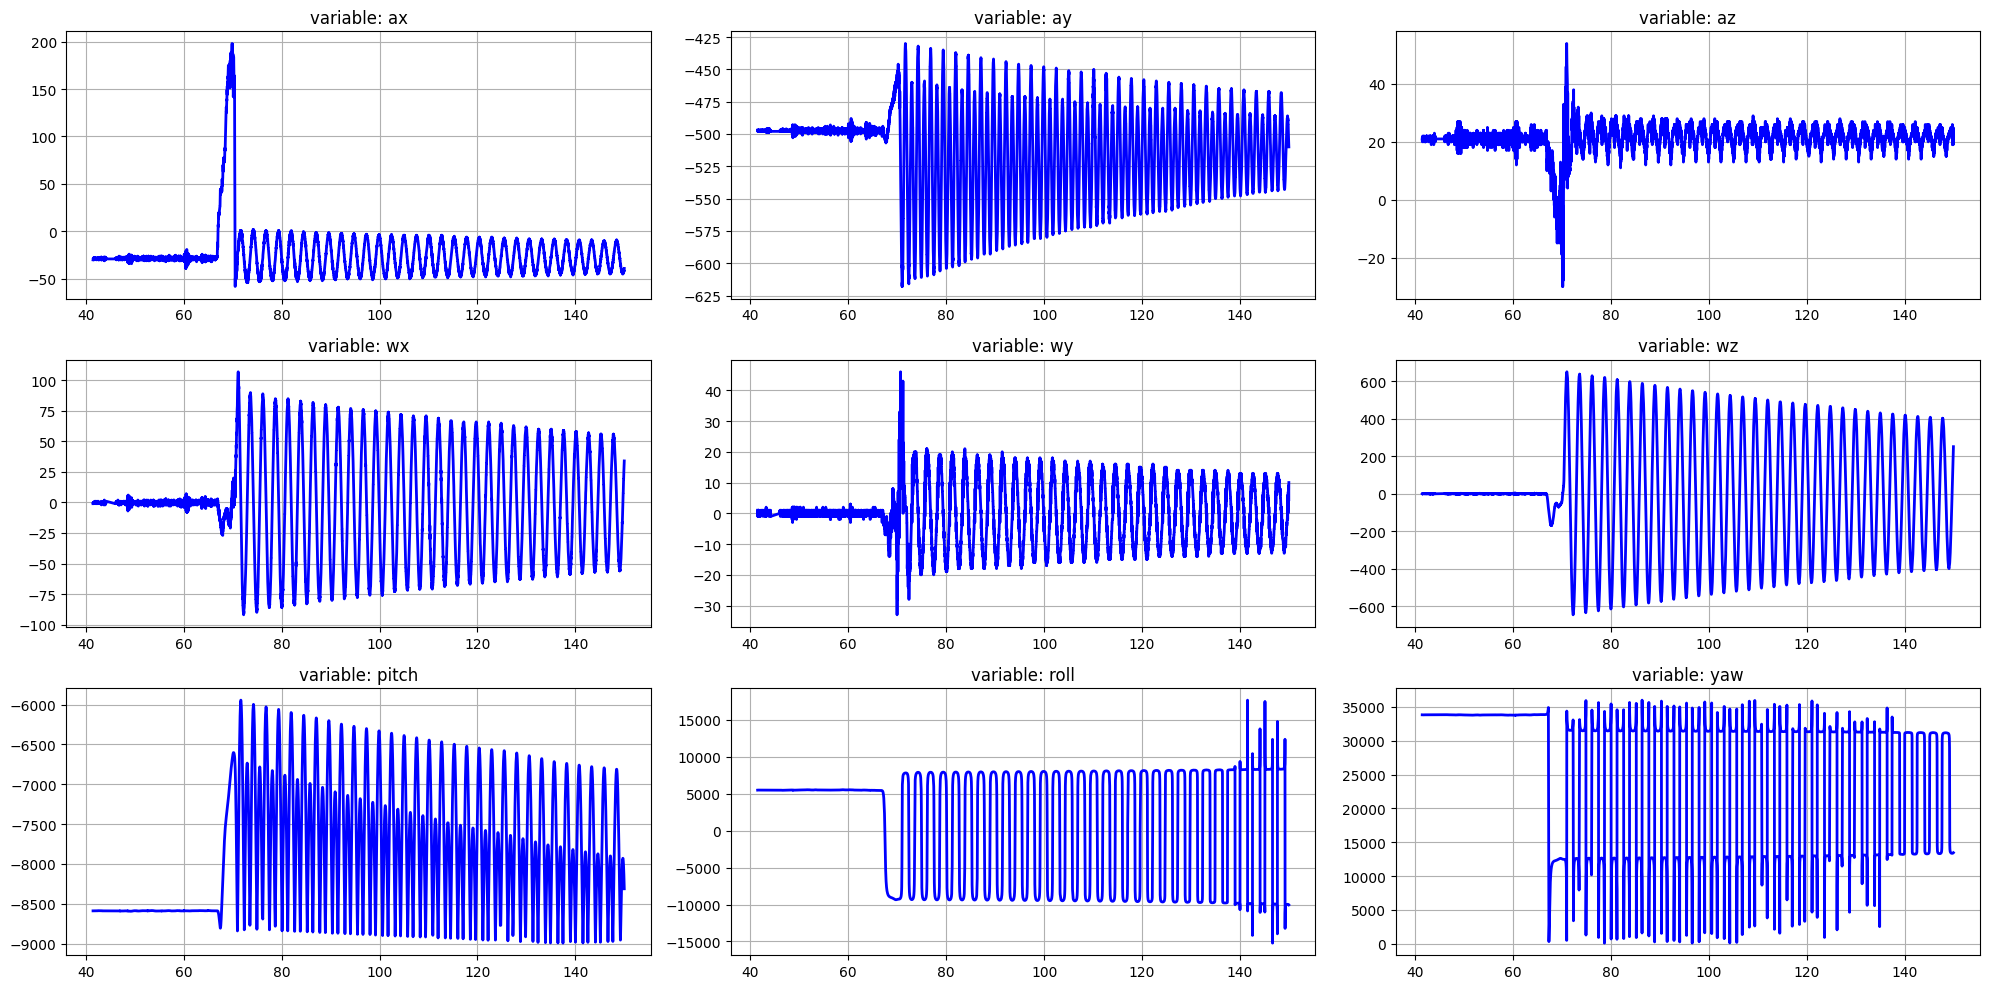

In [9]:
def plotAll(df, limits=None):
    limits = list(limits) if limits is not None else [None, None]

    if limits[0] is None:
        limits[0] = 0

    if limits[1] is None:
        limits[1] = df.time.values[-1]

    target = df.loc[(df.time >= limits[0]) & (df.time <= limits[1])]

    plt.figure(figsize=(20, 10))
    for i, key in enumerate(['ax', 'ay', 'az', 'wx', 'wy', 'wz', 'pitch', 'roll', 'yaw']):
        plt.subplot(3, 3, i+1)
        plt.plot(target.time, target[key], color='blue', linewidth=2)
        plt.title(f'variable: {key}'), plt.grid()

    plt.tight_layout()
    plt.show()


plotAll(df, limits=VIEW_LIMITS)

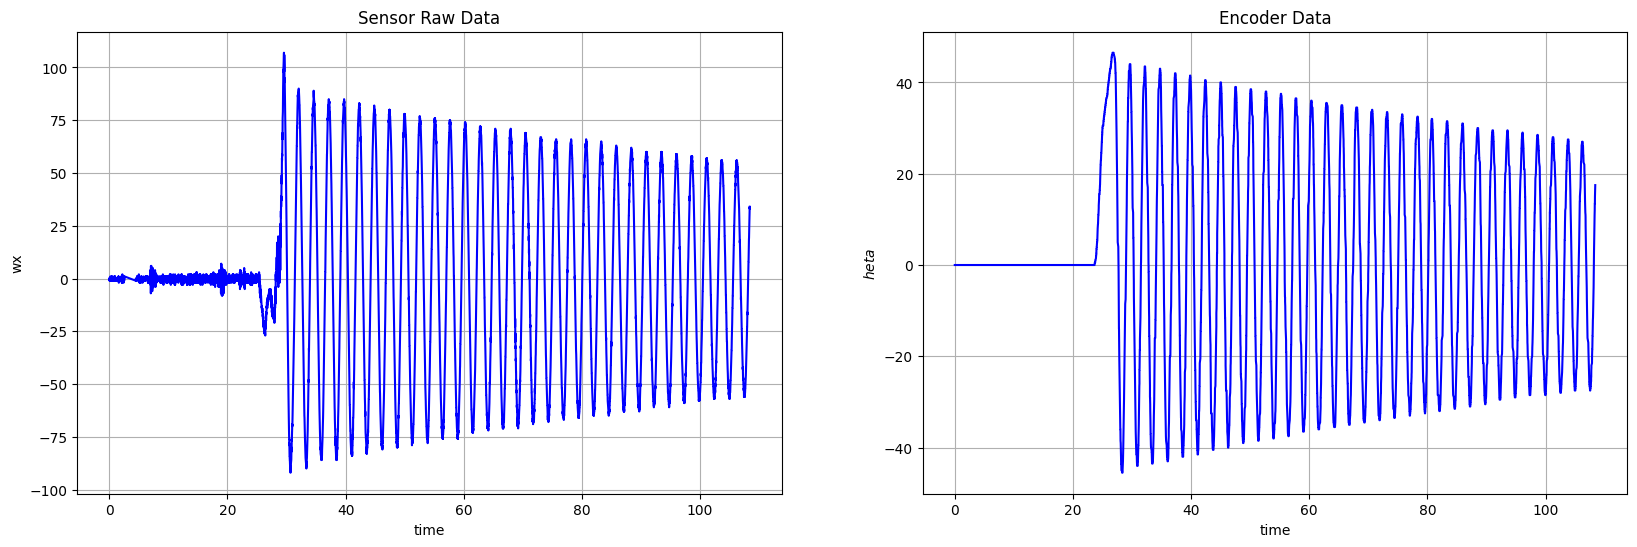

In [10]:
PHASE = 10

if PHASE:
    df['e'] = df['e'].shift(PHASE)
    df = df.dropna(subset=['e']).reset_index(drop=True)


target = df.loc[(df.time > VIEW_LIMITS[0]) & (df.time < VIEW_LIMITS[1])].copy()
target['time'] = target.time.values - target.time.values[0]

plt.figure(figsize=(20, 6))
plt.subplot(1, 2, 1)
plt.plot(target.time, target[f'w{TARGET}'], color='blue')
plt.title('Sensor Raw Data')
plt.xlabel('time'); plt.ylabel(f'w{TARGET}')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(target.time, target.e, color='blue')
plt.title('Encoder Data')
plt.xlabel('time'); plt.ylabel('$\theta$')
plt.grid()

# FILTRANDO ENCODER

In [11]:
from scipy.signal import savgol_filter

In [12]:
WINDOW_SIZE = 51 # Deve ser ímpar. Define o grau de suavização.
POLY_ORDER  = 3  # Polinômio cúbico (bom para manter os picos da senoide)

F = int(1/dt)
F

100

### ENCONTRANDO ANGULOS

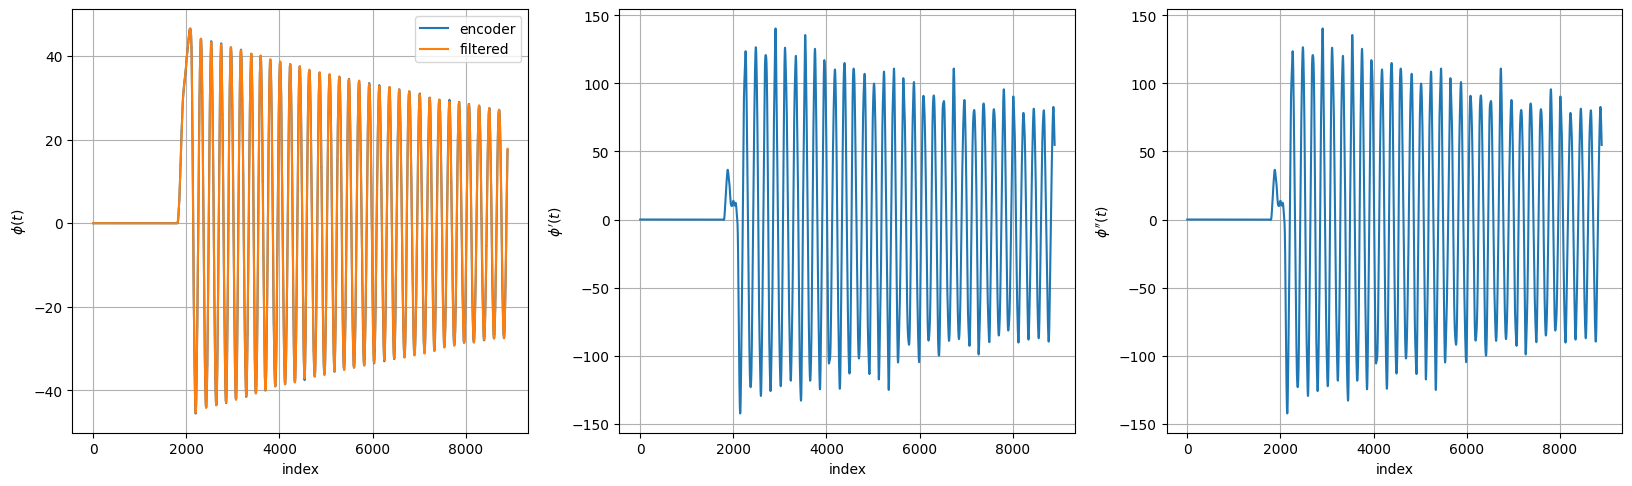

In [13]:
df['phi']    = savgol_filter(df.e.values, window_length=WINDOW_SIZE, polyorder=POLY_ORDER, deriv=0)
df['phi_d']  = savgol_filter(df.phi.values, window_length=WINDOW_SIZE, polyorder=POLY_ORDER, deriv=1, delta=dt)
df['phi_dd'] = savgol_filter(df.phi.values, window_length=WINDOW_SIZE, polyorder=POLY_ORDER, deriv=2, delta=dt)

target = df.loc[(df.time > VIEW_LIMITS[0]) & (df.time < VIEW_LIMITS[1])]
plt.figure(figsize=(20, 5.5))
plt.subplot(1, 3, 1)
plt.plot(target.e, label='encoder')
plt.plot(target.phi, label='filtered')
plt.grid(); plt.legend()
plt.xlabel('index'); plt.ylabel('$ϕ(t)$')

plt.subplot(1, 3, 2)
plt.plot(target.phi_d)
plt.xlabel('index'); plt.ylabel("$ϕ'(t)$")
plt.grid()

plt.subplot(1, 3, 3)
plt.plot(target.phi_d)
plt.xlabel('index'); plt.ylabel("$ϕ''(t)$")
plt.grid()
plt.show()

### ENCONTRANDO ACELERAÇÕES

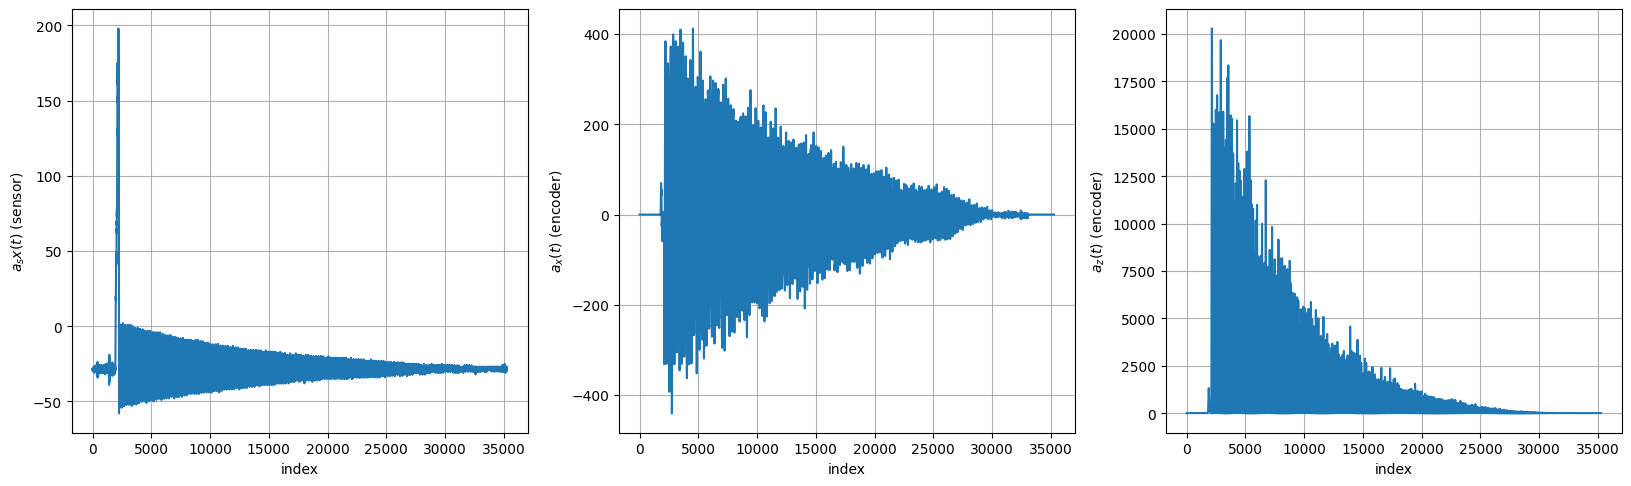

In [14]:
p = 1
g = 9.80665

phi    = df.phi.values
phi_d  = df.phi_d.values
phi_dd = df.phi_dd.values

ax = p*phi_dd   + g*np.sin(phi)
az = p*phi_d**2 + g*np.cos(phi)

plt.figure(figsize=(20, 5.5))
plt.subplot(1, 3, 1)
plt.plot(df.ax)
plt.grid()
plt.xlabel('index'); plt.ylabel('$a_sx(t)$ (sensor)')

plt.subplot(1, 3, 2)
plt.plot(ax)
plt.xlabel('index'); plt.ylabel("$a_x(t)$ (encoder)")
plt.grid()

plt.subplot(1, 3, 3)
plt.plot(az)
plt.xlabel('index'); plt.ylabel("$a_z(t)$ (encoder)")
plt.grid()
plt.show()

# COMPARAÇÕES SIMPLES

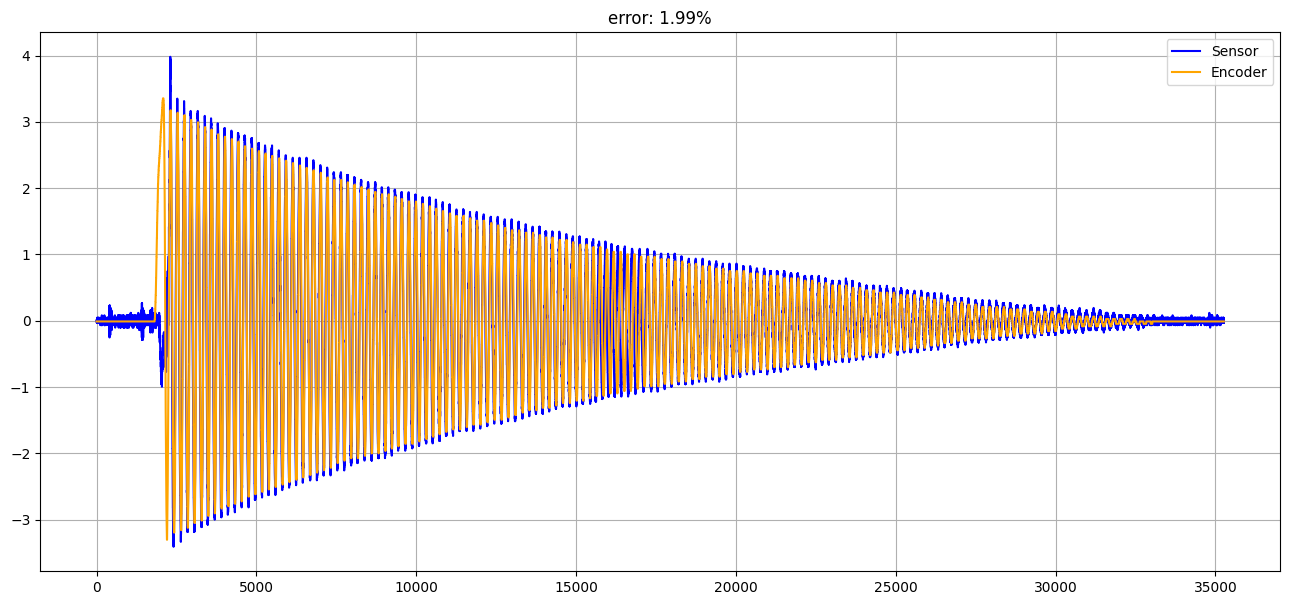

In [15]:
def applyNormalize(data):
    return np.array(data - np.mean(data))/np.std(data)

def getMAPE(real, values):
    return float(np.mean(np.abs((real - values) / real)).round(6))

def compare(data1, data2, normalize=True, phase=0, plot=False):
    data1 = applyNormalize(data1) if normalize else data1
    data2 = applyNormalize(data2) if normalize else data2
    score = wasserstein_distance(data1, data2)
    data2 = data2[phase:]

    n_samples = min(len(data1), len(data2))
    samples1 = np.linspace(0, len(data1)-1, n_samples, dtype=int)
    samples2 = np.linspace(0, len(data2)-1, n_samples, dtype=int)

    data1 = data1[samples1]
    data2 = data2[samples2]

    if plot:
        plt.figure(figsize=(16, 7))
        plt.plot(data1, color='blue', label='Sensor')
        plt.plot(data2, color='orange',  label='Encoder')
        plt.title(f'error: {score*100:.2f}%')
        plt.legend(), plt.grid()
        plt.show()

    return (data1, data2, score)

result = compare(df.wx, df.e, plot=True)

# CURVE FIT

In [16]:
from scipy.optimize import curve_fit, OptimizeWarning
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=OptimizeWarning)

(5000.0, 7000.0)

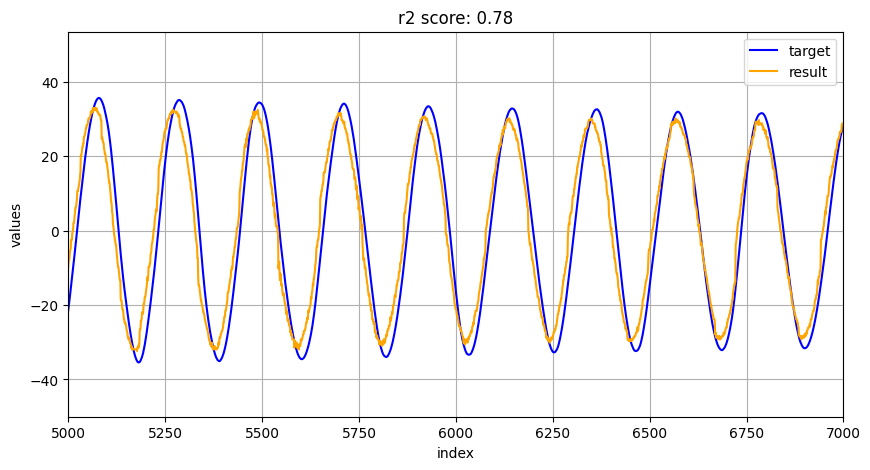

In [17]:
class CurveFit:
    def __init__(self, xData, yData, max_iter=2100000000):
        self.xData = xData
        self.yData = yData
        self.max_iter = max_iter

    def f(self, x, a, b):
        return a*x + b
    
    def update(self):
        result      = curve_fit(self.f, self.xData, self.yData, maxfev=self.max_iter)
        self.coefs  = [float(round(coef, 12)) for coef in list(result[0])]
        self.yModel = self.f(self.xData, *self.coefs)
        
        self.error = self.yData - self.yModel
        self.rmse  = np.sqrt(np.mean(self.error**2))
        self.mae   = np.mean(np.abs(self.error))
        
        ss_res  = np.sum(self.error**2) 
        ss_tot  = np.sum((self.yData - np.mean(self.yData))**2) 
        self.r2 = 1 - (ss_res / ss_tot)

    def plot(self):
        plt.figure(figsize=(10, 5))
        plt.plot(self.yData, color='blue', label='target')
        plt.plot(self.yModel, color='orange', label='result')
        plt.title(f'r2 score: {self.r2:.2f}')
        plt.xlabel('index'); plt.ylabel('values')
        plt.legend()
        plt.grid()


model_ax = CurveFit(df.wx, df.phi)
model_ax.update()
model_ax.plot()
plt.xlim(5000, 7000)